# GoldenCheetah 훈련 흐름 분석

가공된 자전거 라이드 데이터를 이용하여 주간·월간 훈련량의 변화를 확인한다.

In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


project_root = Path("..").resolve()
processed_path = (
    project_root
    / "data"
    / "processed"
    / "goldencheetah_bike_rides_cleaned.csv"
)

rides_df = pd.read_csv(
    processed_path,
    parse_dates=["date"],
)

rides_df.shape

(592, 63)

In [11]:
rides_df["date"].agg(["min", "max"])

min   2005-06-25 14:26:00+00:00
max   2017-07-18 11:01:20+00:00
Name: date, dtype: datetime64[us, UTC]

In [12]:
rides_per_year = (
    rides_df["date"]
    .dt.year
    .value_counts()
    .sort_index()
)

rides_per_year

date
2005     21
2006     30
2007     71
2008     69
2009    144
2010     54
2011      2
2012     57
2013     10
2014     70
2015     44
2016     15
2017      5
Name: count, dtype: int64

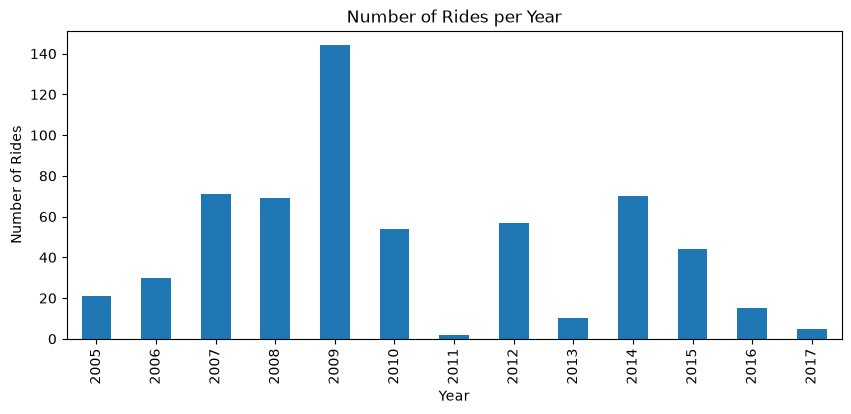

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

rides_per_year.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Number of Rides per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Rides")

plt.show()

In [14]:
monthly_ride_counts = (
    rides_df
    .set_index("date")
    .resample("MS")
    .size()
)

print("전체 월 수:", len(monthly_ride_counts))
print("라이드가 없는 월 수:", (monthly_ride_counts == 0).sum())

전체 월 수: 146
라이드가 없는 월 수: 70


In [15]:
active_months_per_year = (
    (monthly_ride_counts > 0)
    .groupby(monthly_ride_counts.index.year)
    .sum()
)

active_months_per_year

date
2005    7
2006    7
2007    9
2008    7
2009    9
2010    6
2011    2
2012    8
2013    2
2014    7
2015    7
2016    4
2017    1
dtype: int64